INFO:bbtransformer.trainer.exe:Loading data for project='ASD_vs_ADHD_finetune' (target='target_label')
INFO:bbtransformer.trainer.exe:fMRI shape: (374, 150, 414), Subjects: 374
INFO:bbtransformer.trainer.exe:Dataset metadata: {'target': 'target_label', 'n_total': 374, 'n_positive': 271, 'prevalence': 0.7245989441871643, 'feature_dim': 414, 'n_train': 261, 'n_val': 56, 'n_test': 57}


Cohort: 374 subjects (271 cases, 103 controls, 72.5% prevalence)
Splits → Train: 261, Val: 56, Test: 57


INFO:bbtransformer.trainer.exe:Model created on cuda with 29354880 parameters
INFO:bbtransformer.trainer.exe:Pretrained weights loaded from /mnt/movement/users/jaizor/xtra/notebooks/BBT/notebooks/_/master_file/weights/weights_modex.pth


Attempting SAFE load (on CPU first): /mnt/movement/users/jaizor/xtra/notebooks/BBT/notebooks/_/master_file/weights/weights_modex.pth
✓ Successfully loaded 100 layers from: /mnt/movement/users/jaizor/xtra/notebooks/BBT/notebooks/_/master_file/weights/weights_modex.pth


Early stopping at epoch 51 (F1: 1.0000)
✓ Saved SAFE weights (weights_only=True compatible) to: /mnt/movement/users/jaizor/xtra/notebooks/BBT/notebooks/_/master_file/weights/weights_ASD_vs_ADHD_finetune.pth


INFO:bbtransformer.trainer.eval:Evaluation complete: F1=0.9880 | AUC=1.0000 | Acc=0.9825 | Brier=0.2146
INFO:bbtransformer.trainer.exe:Performance Metrics:
INFO:bbtransformer.trainer.exe:  Accuracy:  0.9825
INFO:bbtransformer.trainer.exe:  Precision: 0.9762
INFO:bbtransformer.trainer.exe:  Recall:    1.0000
INFO:bbtransformer.trainer.exe:  F1 Score:  0.9880
INFO:bbtransformer.trainer.exe:  ROC-AUC:   1.0000
INFO:bbtransformer.trainer.exe:Computing permutation importance (metric=loss, repeats=2)
INFO:bbtransformer.trainer.rank:Calculating permutation importance (loss) for 414 brain regions...
Permuting regions: 100%|██████████| 414/414 [02:26<00:00,  2.82it/s]
INFO:bbtransformer.trainer.exe:Permutation importance computation complete.
INFO:bbtransformer.trainer.viz:Saved figure to /mnt/movement/users/jaizor/xtra/notebooks/BBT/notebooks/_/master_file/results/ASD_vs_ADHD_finetune_results.png


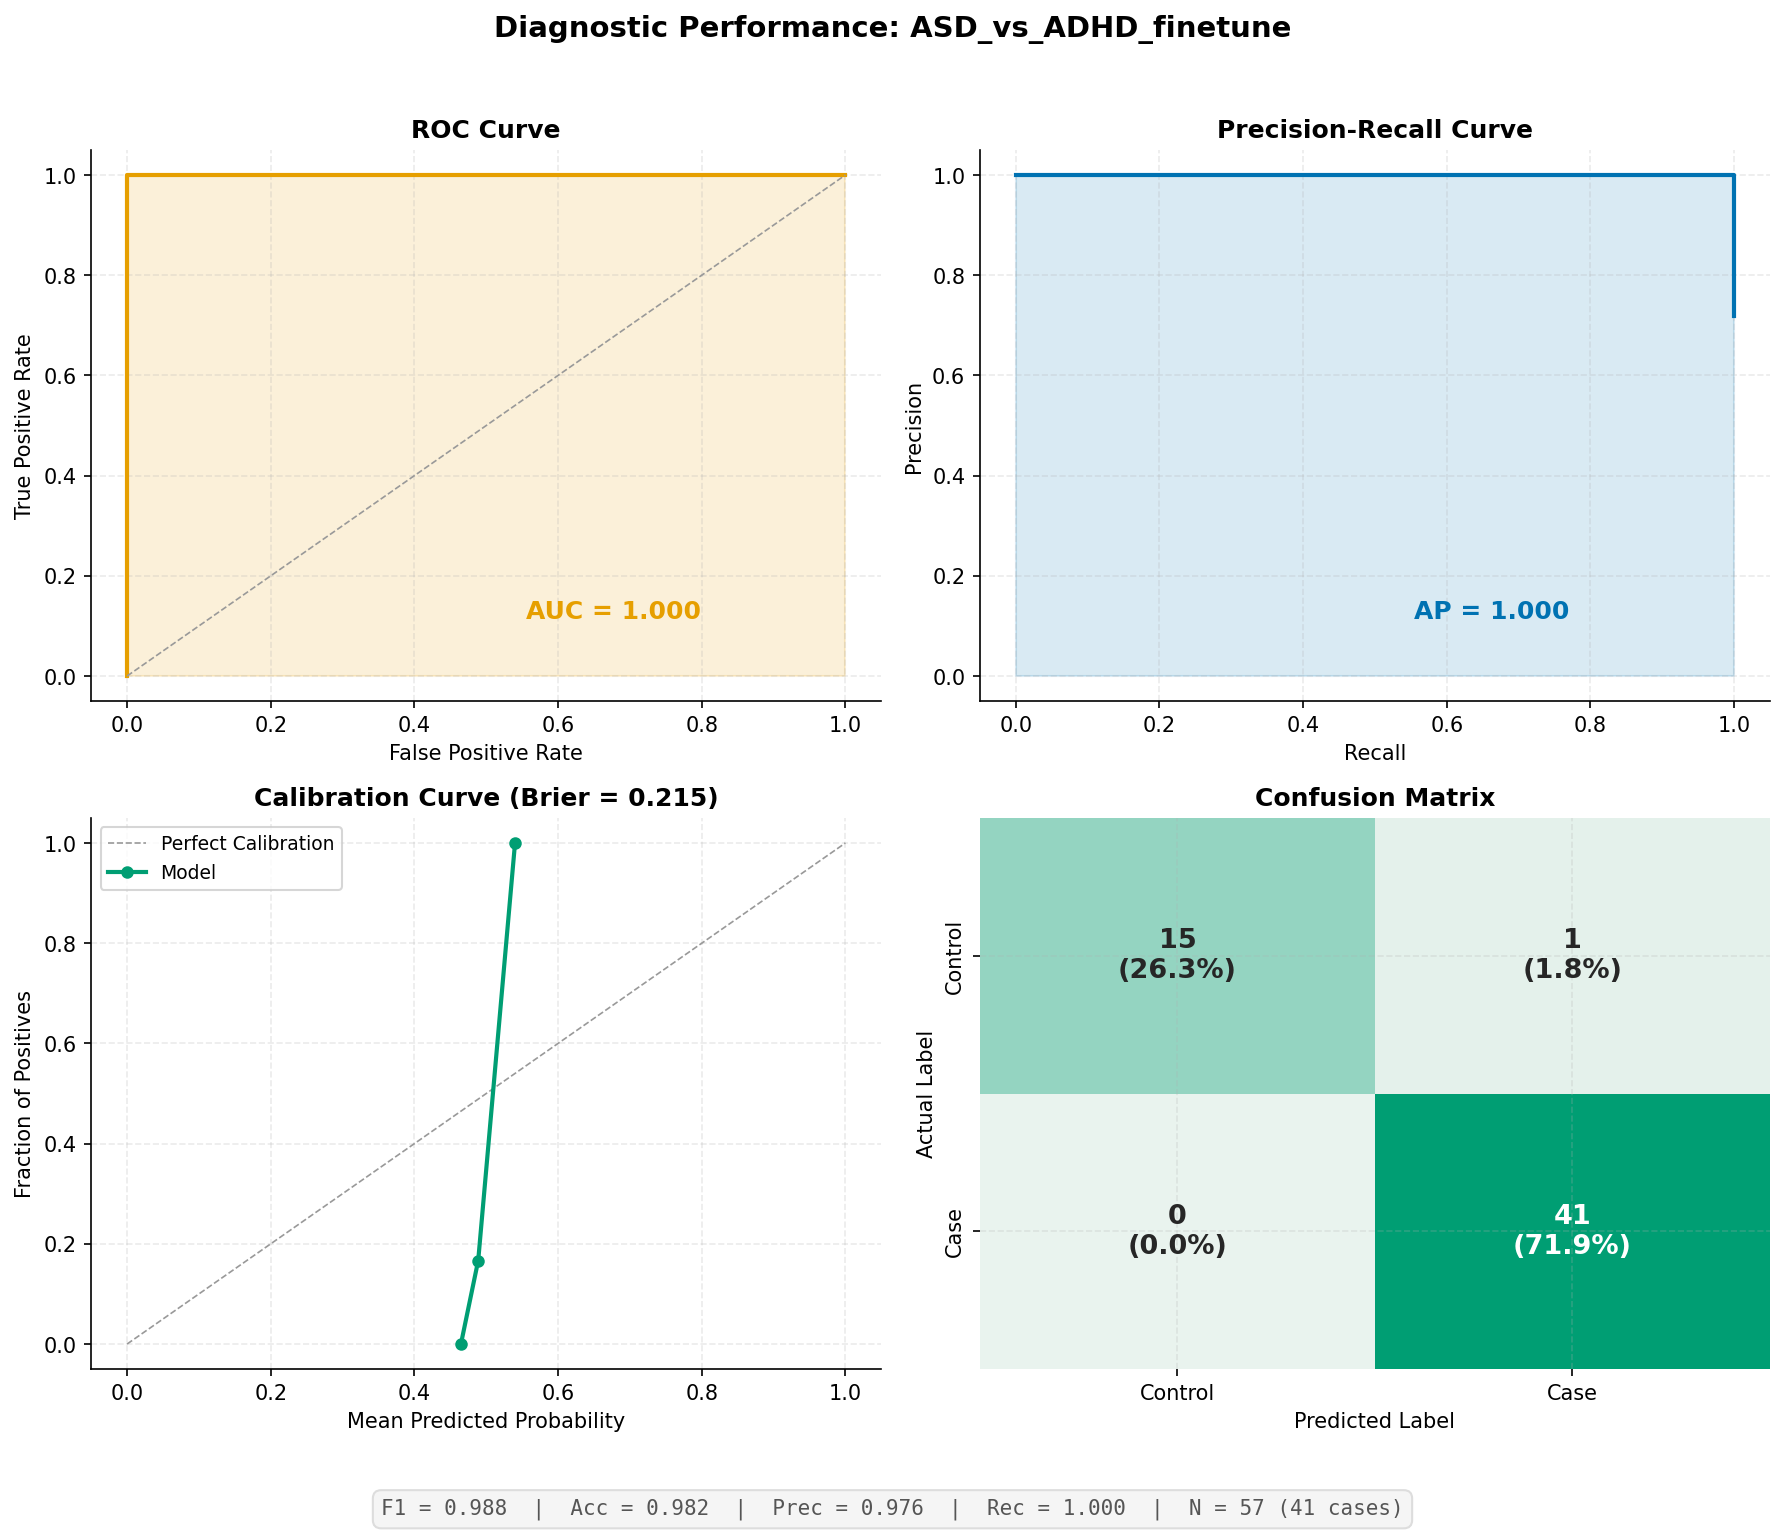

INFO:bbtransformer.trainer.rank:Saved top 5 features to: /mnt/movement/users/jaizor/xtra/notebooks/BBT/notebooks/_/master_file/results/importance_ASD_vs_ADHD_finetune.csv
INFO:bbtransformer.trainer.viz:Saved figure to /mnt/movement/users/jaizor/xtra/notebooks/BBT/notebooks/_/master_file/results/importance_ASD_vs_ADHD_finetune_plot.png


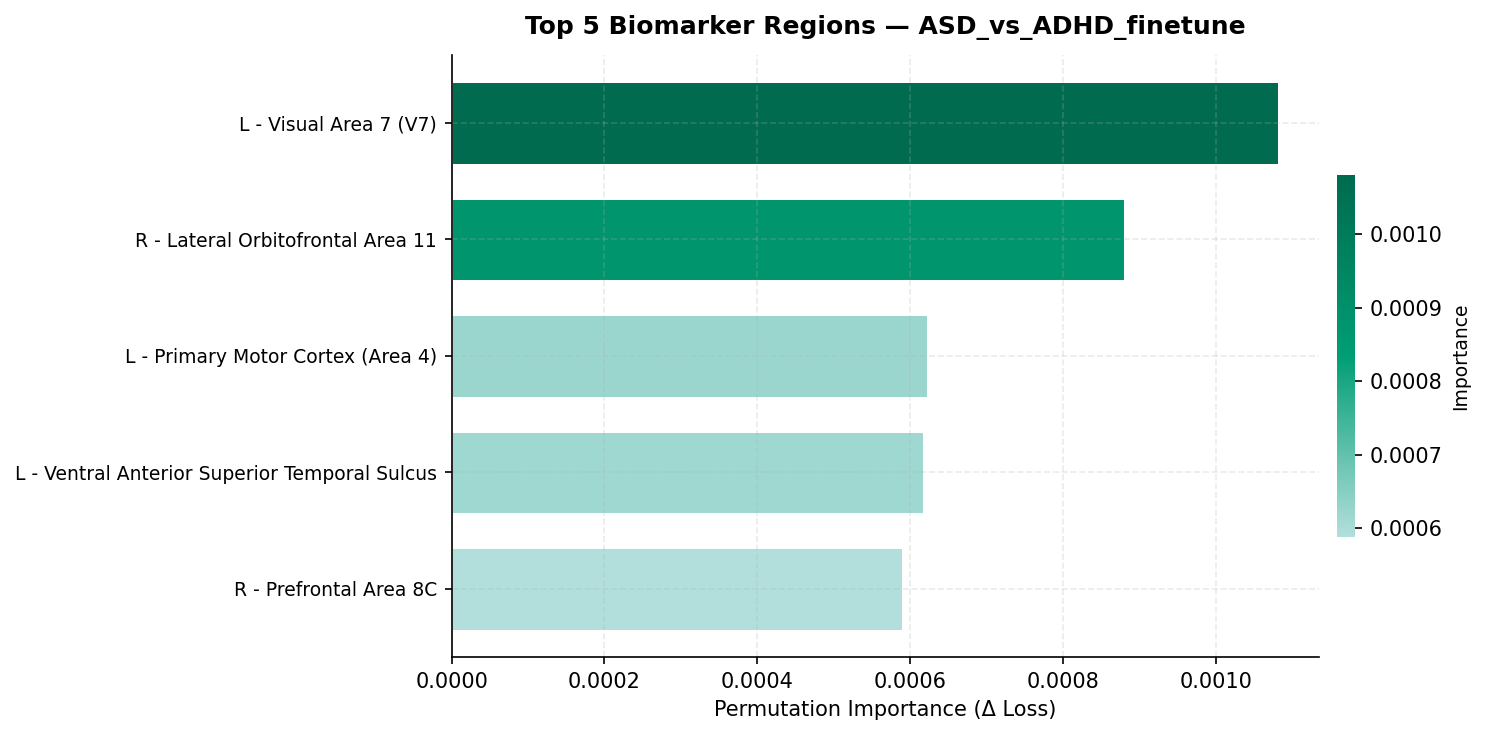

INFO:bbtransformer.trainer.viz:Unified atlas found: /mnt/movement/users/jaizor/.local/lib/python3.13/site-packages/gt_map/data/GT_414ROIs_atlas.nii.gz


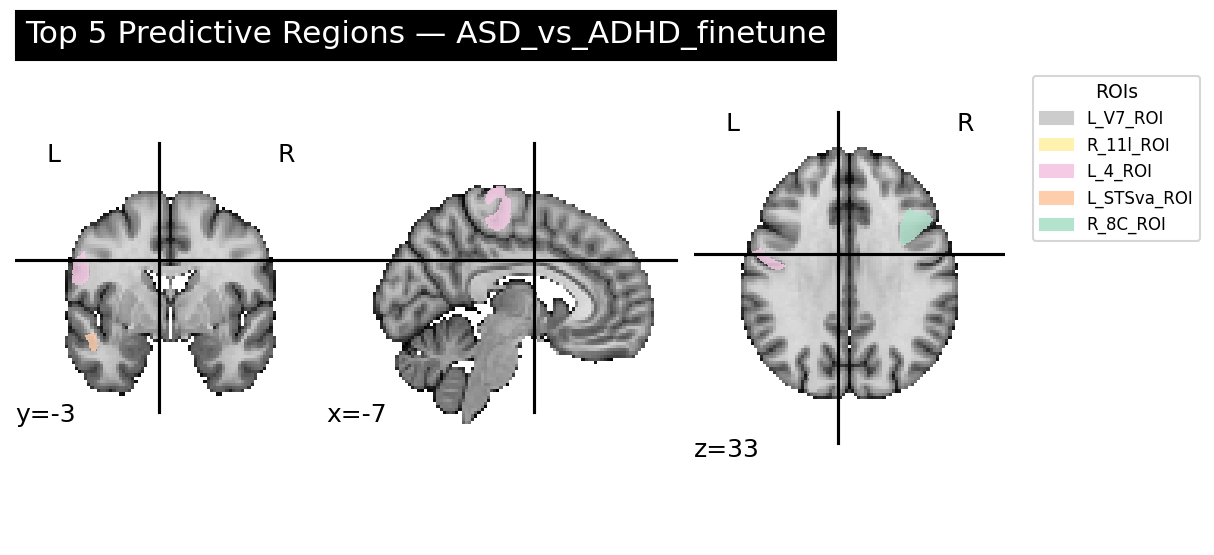

INFO:bbtransformer.trainer.viz:Saved figure to /mnt/movement/users/jaizor/xtra/notebooks/BBT/notebooks/_/master_file/results/network_ASD_vs_ADHD_finetune.png


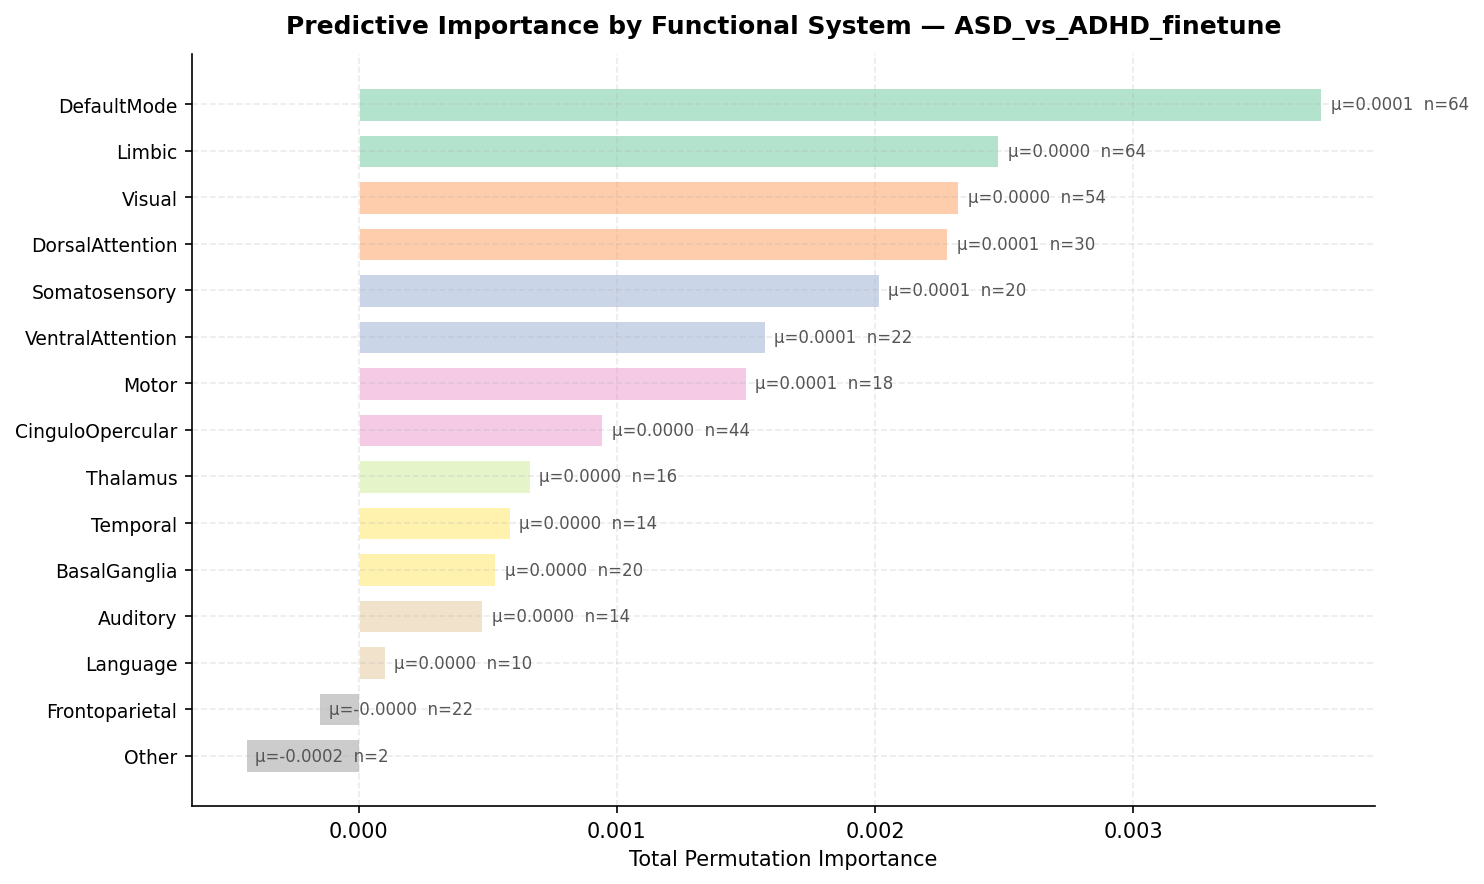

INFO:bbtransformer.trainer.exe:Results saved to JSON: /mnt/movement/users/jaizor/xtra/notebooks/BBT/notebooks/_/master_file/results/ASD_vs_ADHD_finetune_results.json
INFO:bbtransformer.trainer.exe:Pipeline complete for project: ASD_vs_ADHD_finetune
INFO:root:Pipeline complete | F1: 0.9880 | AUC: 1.0000 | Project: ASD_vs_ADHD_finetune


In [1]:
"""Fine-tune BBTransformer on ASD vs ADHD cohort."""

import logging
from pathlib import Path

from bbtransformer.trainer.exe import run_analysis

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
)


# BASE_DIR / "/absolute/path" produces an invalid double path.
# Use the absolute path directly since it is already complete.
DATA_PATH = "/mnt/movement/users/jaizor/xtra/data/fmri/chrt/fmri_ASD_vs_ADHD.npz"
PHENO_PATH = "/mnt/movement/users/jaizor/xtra/data/fmri/chrt/pheno_ASD_vs_ADHD.csv"
PRETRAINED_WEIGHTS = "/mnt/movement/users/jaizor/xtra/notebooks/BBT/notebooks/_/master_file/weights/weights_modex.pth"

results = run_analysis(
    # --- DATA IDENTIFICATION ---
    target_column="target_label",
    project_name="ASD_vs_ADHD_finetune",  # NEW: decouples output naming from target column
    data_path=DATA_PATH,
    pheno_path=PHENO_PATH,
    base_dir=None,

    # --- PROJECT STRUCTURE ---
    project_root=".",
    use_pretrained=True,
    pretrained_weight_file=PRETRAINED_WEIGHTS,  # Absolute path now supported natively

    # --- TRAINING HYPERPARAMETERS ---
    training_config={
        "epochs": 500,
        "lr": 1e-5,
        "weight_decay": 1.14e-06,
        "patience": 50,
    },
    early_stop_metric="f1",
    use_focal_loss=False,

    # --- MODEL ARCHITECTURE ---
    model_config=None,

    # --- IMPORTANCE ANALYSIS ---
    compute_importance=True,
    importance_metric="loss",
    importance_n_repeats=2,

    # --- REPRODUCIBILITY AND HARDWARE ---
    random_seed=42,
    device=None,
    batch_size=64,  # NEW: configurable batch size (was hardcoded to 64 before)

    # --- OUTPUT CONTROL ---
    save_plots=True,
    save_json=True,
)

logging.info(
    "Pipeline complete | F1: %.4f | AUC: %.4f | Project: %s",
    results["metrics"]["f1"],
    results["metrics"]["roc_auc"],
    results["project_name"],
)